Calculando zonas de decisión para OVO-Probabilistic SVM, por favor espera...


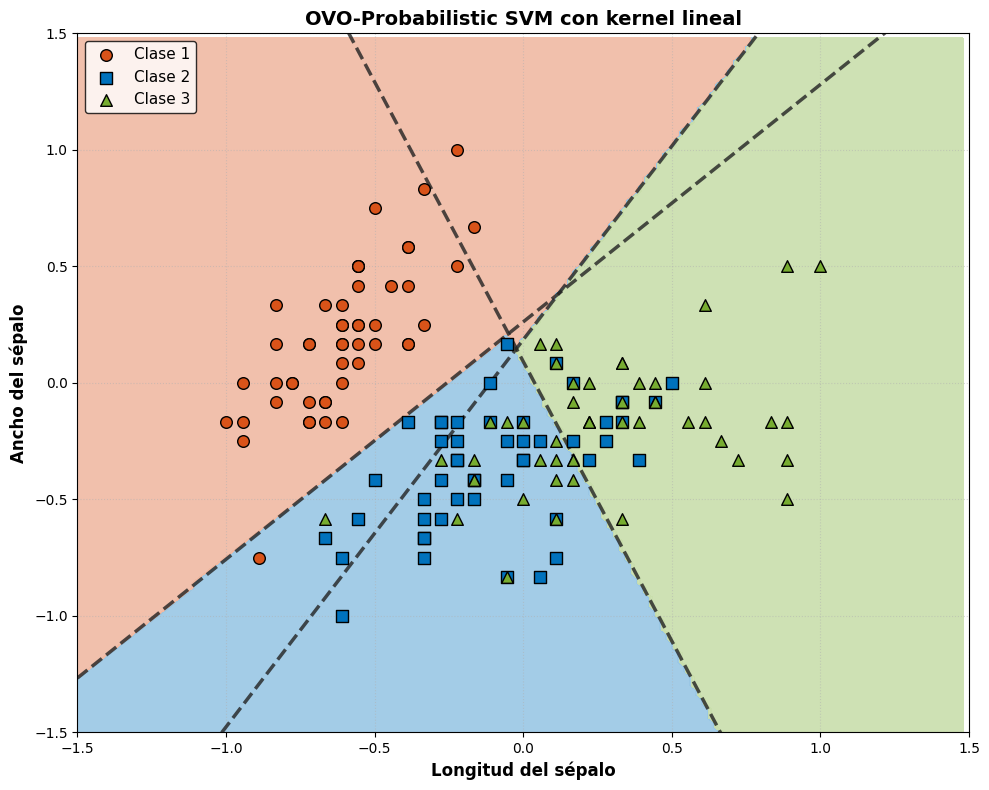

In [3]:
# =========================================================
# Gráfica de hiperplanos y Regiones para OVA y OVO (Probabilistic SVM)
# =========================================================

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import time
import cvxpy as cp
from sklearn.metrics import balanced_accuracy_score
from matplotlib.colors import ListedColormap

# ====================================================================
# Función Auxiliar Matemática: PROBABILISTIC SVM (PSVM)
# ====================================================================
def solve_binary_psvm(X_train, Y_train, C, epsilon=0.5):
    """
    Resuelve la formulación exacta de un PSVM de acuerdo a psvm_primal_cvx.m:
    Minimiza: 0.5*sum_square(w) + C * sum(xi) / epsilon
    Sujeto a: Y_train * (X_train * w + b - 0.5) >= 0.5 * epsilon - xi
              X_train * w + b >= 0
              X_train * w + b <= 1
              xi >= 0
    """
    m, n = X_train.shape
    w = cp.Variable(n)
    b = cp.Variable()
    xi = cp.Variable(m)
    
    # 1. Función objetivo fidedigna al archivo .m de MATLAB
    objective = cp.Minimize(0.5 * cp.sum_squares(w) + C * cp.sum(xi) / epsilon)
    
    # 2. Restricciones reales de probabilidad del PSVM Primal
    constraints = [
        cp.multiply(Y_train, X_train @ w + b - 0.5) >= 0.5 * epsilon - xi,
        X_train @ w + b >= 0,
        X_train @ w + b <= 1,
        xi >= 0
    ]
    prob = cp.Problem(objective, constraints)
    
    prob.solve() 
    
    if w.value is None:
        raise ValueError("El solver falló al resolver la ecuación del PSVM. Revisa C o los datos.")
        
    return w.value, float(b.value)

# ====================================================================
# 1. Implementación OVA (One-Vs-All) para Probabilistic SVM
# ====================================================================
def Predi_OVA_PSVM(Xtr, Ytr, Xte, Yte, FunPara, T):
    C = FunPara.get('c', 1.0)
    epsilon = FunPara.get('epsilon', 0.5)
    m, n = Xtr.shape
    mt = Xte.shape[0]
    
    W = np.zeros((n, T))
    Bias = np.zeros(T)
    Fk_Test = np.zeros((mt, T))
    
    t0 = time.time()
    
    for k in range(1, T + 1):
        idx_k = np.where(Ytr == k)[0]
        idx_not_k = np.setdiff1d(np.arange(m), idx_k)
        
        X_k = Xtr[idx_k, :]
        X_not_k = Xtr[idx_not_k, :]
        
        X_bin = np.vstack((X_k, X_not_k))
        Y_bin = np.hstack((np.ones(len(idx_k)), -np.ones(len(idx_not_k))))
        
        w_val, b_val = solve_binary_psvm(X_bin, Y_bin, C, epsilon)
        
        W[:, k-1] = w_val
        Bias[k-1] = b_val
        
        Fk_Test[:, k-1] = Xte @ w_val + b_val
        
    Tfinal = time.time() - t0
    
    pred_classes = np.argmax(Fk_Test, axis=1) + 1
    bal_accu = balanced_accuracy_score(Yte, pred_classes)
    Loss = 1 - bal_accu 
    
    Sol = {'W': W, 'b': Bias}
    return Loss, bal_accu, Tfinal, Sol

# ====================================================================
# 2. Implementación OVO (One-Vs-One) para Probabilistic SVM
# ====================================================================
def Predi_OVO_PSVM(Xtr, Ytr, Xte, Yte, FunPara, T):
    C = FunPara.get('c', 1.0)
    epsilon = FunPara.get('epsilon', 0.5)
    m, n = Xtr.shape
    mt = Xte.shape[0]
    
    n_hyper = int(T * (T - 1) / 2)
    W = np.zeros((n, n_hyper))
    Bias = np.zeros(n_hyper)
    cont_k = np.zeros((T, mt))
    
    kh = 0
    t0 = time.time()
    
    for i in range(1, T):
        idx_i = np.where(Ytr == i)[0]
        X_i = Xtr[idx_i, :]
        
        for j in range(i + 1, T + 1):
            idx_j = np.where(Ytr == j)[0]
            X_j = Xtr[idx_j, :]
            
            X_bin = np.vstack((X_i, X_j))
            Y_bin = np.hstack((np.ones(len(idx_i)), -np.ones(len(idx_j))))
            
            w_val, b_val = solve_binary_psvm(X_bin, Y_bin, C, epsilon)
            
            W[:, kh] = w_val
            Bias[kh] = b_val
            
            # Evaluación usando el umbral correcto de probabilidad (0.5)
            preds = np.sign(Xte @ w_val + b_val - 0.5)
            for kl in range(mt):
                if preds[kl] >= 0:
                    cont_k[i-1, kl] += 1
                else:
                    cont_k[j-1, kl] += 1
            kh += 1
            
    Tfinal = time.time() - t0
    
    pred_classes = np.argmax(cont_k, axis=0) + 1
    bal_accu = balanced_accuracy_score(Yte, pred_classes)
    Loss = 1 - bal_accu
    
    Sol = {'W': W, 'b': Bias}
    return Loss, bal_accu, Tfinal, Sol

# ================== Cargar dataset ==================
# Ajusta la ruta si es necesario
ruta_dataset = r"C:\Users\loren\Downloads\TESIS\Multclass\Dataset_Multiclass\irisMn.mat"
try:
    data = sio.loadmat(ruta_dataset)
    X = data['X']
    Y = data['Y'].flatten().astype(int)
except FileNotFoundError:
    print("No se encontró el .mat. Usando datos sintéticos de Iris para prueba.")
    from sklearn.datasets import load_iris
    X, Y = load_iris(return_X_y=True)
    Y = Y + 1  # Ajustar a clases 1, 2, 3

X2 = X[:, :2]  # Solo dos variables para graficar
classes = np.unique(Y)
T = len(classes)

# ================== Selección y EJECUCIÓN del modelo ==================
Modelo = 2   # ELIGE TU MODELO AQUÍ (1: OVA-PSVM, 2: OVO-PSVM)

FunPara = {'kerfPara': {'type': 'lin'}, 'c': 0, 'epsilon': 0.5}

if Modelo == 1:
    modelName = 'OVA-Probabilistic SVM'
    FunPara['c'] = 2**(-6)
    Loss, bal_accu, Tf, Sol = Predi_OVA_PSVM(X2, Y, X2, Y, FunPara, T)
    
elif Modelo == 2:
    modelName = 'OVO-Probabilistic SVM'
    FunPara['c'] = 2**(-6)
    Loss, bal_accu, Tf, Sol = Predi_OVO_PSVM(X2, Y, X2, Y, FunPara, T)

# ================== Extracción de resultados ==================
W = Sol['W']
Bias = Sol['b'].flatten()
nHyper = W.shape[1]

# ================== Límites del gráfico y Malla (Grid) ==================
xmin, xmax = X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5
ymin, ymax = X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5

# Crear malla densa de puntos
paso = 0.02
xx, yy = np.meshgrid(np.arange(xmin, xmax, paso),
                     np.arange(ymin, ymax, paso))
X_grid = np.c_[xx.ravel(), yy.ravel()]
mt_grid = X_grid.shape[0]

# ================== Predecir Zonas de Decisión ==================
print(f"Calculando zonas de decisión para {modelName}, por favor espera...")
if Modelo == 1:
    # Predicción matricial OVA
    Fk_Grid = X_grid @ W + Bias
    pred_grid = np.argmax(Fk_Grid, axis=1) + 1

elif Modelo == 2:
    # Predicción por votación OVO usando el umbral real 0.5
    cont_k = np.zeros((T, mt_grid))
    kh = 0
    for i in range(1, T):
        for j in range(i + 1, T + 1):
            w_val = W[:, kh]
            b_val = Bias[kh]
            preds = np.sign(X_grid @ w_val + b_val - 0.5)
            cont_k[i-1, preds >= 0] += 1
            cont_k[j-1, preds < 0] += 1
            kh += 1
    pred_grid = np.argmax(cont_k, axis=0) + 1

Z = pred_grid.reshape(xx.shape)

# ================== Configuración del Gráfico ==================
plt.figure(figsize=(10, 8))

# 1. Paleta de Colores RGB Base (para los puntos y las líneas)
colores_base = np.array([
    [0.8500, 0.3250, 0.0980],  # Naranja (Clase 1)
    [0.0000, 0.4470, 0.7410],  # Azul    (Clase 2)
    [0.4660, 0.6740, 0.1880],  # Verde   (Clase 3)
    [0.9290, 0.6940, 0.1250]   # Amarillo (si hay más clases)
])

# 2. Generar el color de las Regiones (Mezclando un 60% de blanco para hacerlos pastel)
colores_fondo = colores_base[:T] + 0.6 * (1 - colores_base[:T])
cmap_fondo = ListedColormap(colores_fondo)

# Graficar el fondo de color
plt.contourf(xx, yy, Z, alpha=0.9, cmap=cmap_fondo)

# Graficar los puntos (dataset)
marcadores = ['o', 's', '^', 'D', 'v']
for i, c in enumerate(classes):
    idx = (Y == c)
    plt.scatter(X2[idx, 0], X2[idx, 1], 
                color=colores_base[i], 
                marker=marcadores[i % len(marcadores)], 
                edgecolors='black', # Borde negro para máximo contraste
                linewidth=1,
                label=f'Clase {c}', s=70, zorder=3)

# ================== Graficar hiperplanos ==================
t_vals = np.linspace(xmin, xmax, 300)

for k in range(nHyper):
    wk = W[:, k]
    bk = Bias[k]
    
    # Despeje geométrico corregido basado en la frontera w*x + b = 0.5
    if abs(wk[1]) > 1e-12:
        yline_k = (0.5 - bk - wk[0] * t_vals) / wk[1]
        # Línea negra punteada semitransparente para hiperplanos
        plt.plot(t_vals, yline_k, linewidth=2.5, color='#222222', linestyle='--', alpha=0.8, zorder=2)
    else:
        xline_k = (0.5 - bk) / wk[0]
        plt.axvline(x=xline_k, linewidth=2.5, color='#222222', linestyle='--', alpha=0.8, zorder=2)

# ================== Detalles Estéticos ==================
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.xlabel('Longitud del sépalo', fontsize=12, fontweight='bold')
plt.ylabel('Ancho del sépalo', fontsize=12, fontweight='bold')

# Título ajustado para indicar explícitamente "Probabilistic SVM"
plt.title(f'{modelName} con kernel lineal', fontsize=14, fontweight='bold')

# Leyenda con fondo semitransparente
plt.legend(loc='best', fontsize=11, framealpha=0.8, edgecolor='black')
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()